<h1>Exploratory Data Analysis: Data Visualization. Practical Assignment<h1>

**Objective of the Practical Assignment**

In this practical assignment, I focus on learning how to work with anomalies in data, create visualizations, and identify relationships between variables using the Matplotlib library.

<h2> What is included in the practical assignment </h2>

1) I load the dataset and examine it.
2) I analyze the data for anomalies and handle outliers.
3) I create visualizations for numerical variables.
4) I create visualizations for categorical variables.
5) I explore relationships within the data.

#Task

In this practical assignment, I continue exploring and preparing the data for the modeling stage.

I work with a small sample from a collection of used cars listed for sale in the United States, provided in the file data/vehicles_dataset_upd.csv. Using this dataset, I will build my first classification model to determine the price category of a used car based on its characteristics.

In this assignment, I further develop my skills in data visualization and anomaly detection using matplotlib, as well as in identifying relationships within the data.


## Dataset Description:
- `id`: record identifier;
- `url`: URL listing URL;
- `region`: region;
- `region_url`: region URL;
- `price`: price;
- `year`: year of manufacture;
- `manufacturer`: manufacturer;
- `model`: model;
- `condition`: condition;
- `cylinders`: number of cylinders;
- `fuel`: fuel type;
- `odometer`: mileage;
- `title_status`: title status;
- `transmission`: transmission type;
- `VIN`: vehicle identification number;
- `drive`: drive type;
- `size`: size;
- `type`: body type;
- `paint_color`: color;
- `image_url`: image URL;
- `description`: listing description;
- `county`: country;
- `state`: state;
- `lat`: latitude;
- `long`: longitude;
- `posting_date`: posting date of the listing;
- `price_category`: price category.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

### Task 1. Identifying anomalies in vehicle prices

1. I load the dataset from data/vehicles_dataset_upd.csv and display the first 5 records.


In [3]:
df = pd.read_csv('vehicles_dataset_upd.csv')
df.head()

,id,url,region,region_url,price,year,manufacturer,model,fuel,odometer,title_status,transmission,image_url,description,state,lat,long,posting_date,price_category,date
0,7308295377,https://chattanooga.craigslist.org/ctd/d/chatt...,chattanooga,https://chattanooga.craigslist.org,54990,2020,ram,2500 crew cab big horn,diesel,27442,clean,other,https://images.craigslist.org/00N0N_1xMPvfxRAI...,Carvana is the safer way to buy a car During t...,tn,35.060000,-85.250000,2021-04-17T12:30:50-0400,high,2021-04-17 16:30:50+00:00
1,7316380095,https://newjersey.craigslist.org/ctd/d/carlsta...,north jersey,https://newjersey.craigslist.org,16942,2016,ford,explorer 4wd 4dr xlt,other,60023,clean,automatic,https://images.craigslist.org/00x0x_26jl9F0cnL...,***Call Us for more information at: 201-635-14...,nj,40.821805,-74.061962,2021-05-03T15:40:21-0400,medium,2021-05-03 19:40:21+00:00
2,7313733749,https://reno.craigslist.org/ctd/d/atlanta-2017...,reno / tahoe,https://reno.craigslist.org,35590,2017,volkswagen,golf r hatchback,gas,14048,clean,other,https://images.craigslist.org/00y0y_eeZjWeiSfb...,Carvana is the safer way to buy a car During t...,ca,33.779214,-84.411811,2021-04-28T03:52:20-0700,high,2021-04-28 10:52:20+00:00
3,7308210929,https://fayetteville.craigslist.org/ctd/d/rale...,fayetteville,https://fayetteville.craigslist.org,14500,2013,toyota,rav4,gas,117291,clean,automatic,https://images.craigslist.org/00606_iGe5iXidib...,2013 Toyota RAV4 XLE 4dr SUV Offered by: R...,nc,35.715954,-78.655304,2021-04-17T10:08:57-0400,medium,2021-04-17 14:08:57+00:00
4,7316474668,https://newyork.craigslist.org/lgi/cto/d/baldw...,new york city,https://newyork.craigslist.org,21800,2021,nissan,altima,gas,8000,clean,automatic,https://images.craigslist.org/00V0V_3pSOiPZ3Sd...,2021 Nissan Altima Sv with Only 8 K Miles Titl...,ny,40.654800,-73.609700,2021-05-03T18:32:06-0400,medium,2021-05-03 22:32:06+00:00


2. I plot a histogram of the vehicle price distribution, setting the figure size to 8×5 and the color to `indigo`. I also add a title and label both axes.

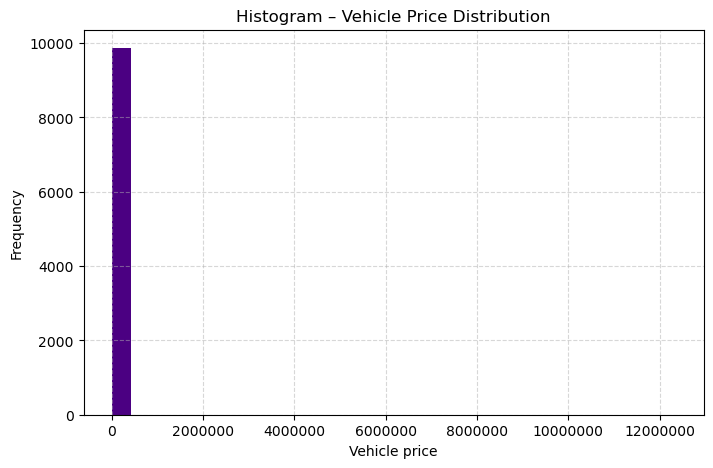

In [26]:
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(df.price,  bins=30, color='indigo')
ax.set_xlabel('Vehicle price')
ax.set_ylabel('Frequency')
ax.set_title('Histogram – Vehicle Price Distribution')
ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.grid(True, linestyle='--', alpha=0.5)

3. The histogram in this form does not clearly represent the actual distribution, but it allows me to conclude that outliers are present.
I plot a boxplot for vehicle prices, setting the figure size to 5×15, and apply formatting to properly display price values. I also add a title and label the axes.

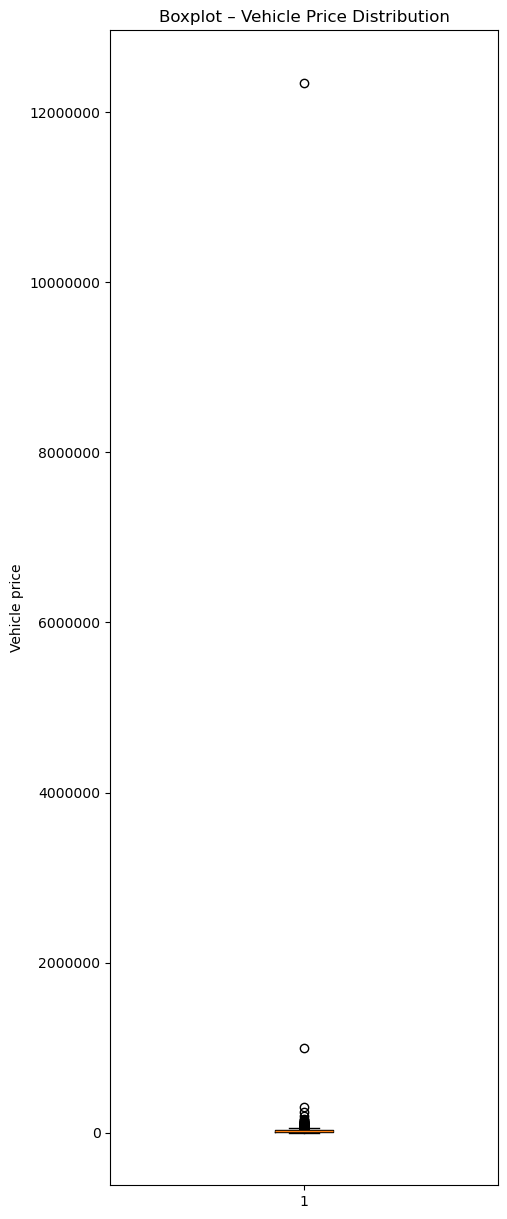

In [27]:
fig, ax = plt.subplots(figsize=(5,15))
ax.boxplot(df.price)
ax.set_ylabel('Vehicle price')
ax.set_title('Boxplot – Vehicle Price Distribution')
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

4. From the boxplot, I can see that outliers do exist, but due to their wide spread, the main part of the plot (the “box”) is barely visible.
I display the descriptive statistics of vehicle prices to examine the values that define the boundaries of the box. I use `apply(lambda x: f"{x:0.3f}")` to present the values in a more readable format.

In [6]:
df.price.describe().apply(lambda x: f'{x:0.3f}')

count        9868.000
mean        20602.005
std        125437.186
min           500.000
25%          7800.000
50%         15590.000
75%         27990.000
max      12345678.000
Name: price, dtype: object

5. I calculate the boundaries for normal vehicle price values using the interquartile range (IQR). Then, I check whether the minimum and maximum values fall within the interval defined by these boundaries.

In [28]:
q25 = df.price.quantile(0.25)
q75 = df.price.quantile(0.75)
igr = q75 - q25
boundaries = (q25 - 1.5 * igr, q75 + 1.5 * igr)
lower, upper = boundaries
print('Boundaries: ', lower, ' - ',  upper)
print('MAX: ', df.price.max())
print('MIN: ', df.price.min())

print("MIN within range:", lower <= df.price.min() <= upper)
print("MAX within range:", lower <= df.price.max() <= upper)

Boundaries:  -22485.0  -  58275.0
MAX:  12345678
MIN:  500
MIN within range: True
MAX within range: False


6. I calculate and display the number of outliers in vehicle prices.

In [29]:
is_outlier = (df.price < boundaries[0]) | (df.price > boundaries[1])
print('Number of outliers in vehicle prices: ',is_outlier.sum())

Number of outliers in vehicle prices:  207


7. I display the records where vehicle prices are considered outliers, sorting them by price. I examine the data to consider whether these outliers might represent special values for the price category or other features, or if they are truly anomalous.

In [9]:
df_ouliers_sorted = df[is_outlier].sort_values(by='price')
df_ouliers_sorted

,id,url,region,region_url,price,year,manufacturer,model,fuel,odometer,title_status,transmission,image_url,description,state,lat,long,posting_date,price_category,date
934,7312212565,https://lasvegas.craigslist.org/cto/d/fresno-d...,las vegas,https://lasvegas.craigslist.org,58500,2013,ram,3500 limited,diesel,57149,clean,automatic,https://images.craigslist.org/00o0o_6VEbwgYoL0...,Only 57K Miles! This 3500 RAM Truck has the 6....,nv,36.746400,-119.639700,2021-04-24T20:46:06-0700,high,2021-04-25 03:46:06+00:00
4783,7308933629,https://omaha.craigslist.org/cto/d/cortland-20...,omaha / council bluffs,https://omaha.craigslist.org,58500,2008,chevrolet,corvette,gas,11000,clean,manual,https://images.craigslist.org/00P0P_kxzGxZwBY9...,2008 Corvette Z06 Wil Cooksey Edition Car nu...,ia,40.445488,-96.713695,2021-04-18T15:53:04-0500,high,2021-04-18 20:53:04+00:00
5977,7310551940,https://cincinnati.craigslist.org/ctd/d/camp-d...,cincinnati,https://cincinnati.craigslist.org,58500,2019,chevrolet,"silverado 2500hd 4wd crew cab 153.7"" ltz",other,50930,clean,automatic,https://images.craigslist.org/01010_ldls5xr3zz...,***Call Us for more information at: 513-453-41...,oh,39.171991,-84.271999,2021-04-21T17:05:31-0400,high,2021-04-21 21:05:31+00:00
8050,7307146509,https://lubbock.craigslist.org/ctd/d/brownfiel...,lubbock,https://lubbock.craigslist.org,58600,2019,ford,f-150,gas,29458,clean,automatic,https://images.craigslist.org/00E0E_6JF7CBAVf7...,Stanley CDJR Brownfield address: 1706 Lubbo...,tx,33.196047,-102.273565,2021-04-15T08:58:48-0500,high,2021-04-15 13:58:48+00:00
4265,7313452917,https://austin.craigslist.org/ctd/d/salem-2016...,austin,https://austin.craigslist.org,58670,2016,chevrolet,other,other,16407,clean,automatic,https://images.craigslist.org/00000_e7iiMwUVq3...,2016 *** Chevrolet Corvette 2LZ Z06*** ...,tx,44.927304,-123.030322,2021-04-27T13:33:32-0500,high,2021-04-27 18:33:32+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6035,7315323093,https://daytona.craigslist.org/ctd/d/orlando-2...,daytona beach,https://daytona.craigslist.org,197999,2015,other,Lamborghini Huracan,gas,33875,clean,other,https://images.craigslist.org/01717_55Ai9omMq5...,CREDIT AMNESTY! SE HABLA ESPANOL !!OPEN SUNDA...,fl,28.466088,-81.396429,2021-05-01T11:48:44-0400,high,2021-05-01 15:48:44+00:00
290,7310897583,https://tucson.craigslist.org/ctd/d/tucson-201...,tucson,https://tucson.craigslist.org,239995,2017,ferrari,488 gtb,gas,6012,clean,automatic,https://images.craigslist.org/00t0t_dN5Wr8nfOx...,2017 Ferrari 488 GTB Coupe2017 Ferrari 488 GTB...,az,32.236075,-110.878886,2021-04-22T09:38:59-0700,high,2021-04-22 16:38:59+00:00
5585,7313998757,https://winchester.craigslist.org/ctd/d/manass...,winchester,https://winchester.craigslist.org,304995,2021,porsche,911,gas,22,clean,automatic,https://images.craigslist.org/00r0r_gh2TnrNdSu...,2021 PORSCHE 911 Turbo Offered by: Insider...,va,38.762669,-77.461754,2021-04-28T15:49:25-0400,high,2021-04-28 19:49:25+00:00
9663,7305237859,https://delaware.craigslist.org/cto/d/delaware...,delaware,https://delaware.craigslist.org,1000000,2022,other,Any make any model,other,283995,clean,other,https://images.craigslist.org/00S0S_k3A68PVXRC...,We come to you and give you an easy quick tran...,de,39.572500,-75.595700,2021-04-11T13:51:42-0400,high,2021-04-11 17:51:42+00:00


8. I display the last 15 records in the previously sorted dataframe of outliers to examine the features of the most expensive vehicles.

In [10]:
df_ouliers_sorted.tail(15)

,id,url,region,region_url,price,year,manufacturer,model,fuel,odometer,title_status,transmission,image_url,description,state,lat,long,posting_date,price_category,date
4073,7311841843,https://albuquerque.craigslist.org/ctd/d/albuq...,albuquerque,https://albuquerque.craigslist.org,120000,2021,chevrolet,corvette c8 z51,gas,10,clean,automatic,https://images.craigslist.org/00z0z_99zXyVvNmm...,New arrival Z51 Call or text annamarie for d...,nm,35.081800,-106.648200,2021-04-24T08:38:45-0600,high,2021-04-24 14:38:45+00:00
9072,7308732637,https://evansville.craigslist.org/ctd/d/evansv...,evansville,https://evansville.craigslist.org,123456,2006,jeep,wrangler,gas,12345,clean,other,https://images.craigslist.org/00I0I_2IkqjY69Zq...,Very Nice TJ jeeps and a few LJ jeep wranglers...,in,38.025845,-87.596457,2021-04-18T09:55:42-0500,high,2021-04-18 14:55:42+00:00
1674,7303398175,https://pullman.craigslist.org/cto/d/pullman-6...,pullman / moscow,https://pullman.craigslist.org,123456,1995,other,cadvwrambuick,gas,283995,missing,other,https://images.craigslist.org/00i0i_5iBwIawLgG...,I have several cars to get rid of: A '65 Ramb...,id,46.735200,-117.172900,2021-04-07T15:57:23-0700,high,2021-04-07 22:57:23+00:00
2963,7308463617,https://jacksonville.craigslist.org/cto/d/pont...,jacksonville,https://jacksonville.craigslist.org,129000,2018,mercedes-benz,benz amg gt c,gas,4000,clean,automatic,https://images.craigslist.org/00C0C_bN8j4IcEqW...,Beautiful car in perfect condition. Very rare ...,fl,30.122300,-81.362700,2021-04-17T16:48:42-0400,high,2021-04-17 20:48:42+00:00
5076,7314445453,https://boston.craigslist.org/gbs/ctd/d/methue...,boston,https://boston.craigslist.org,129995,2007,ferrari,f430 spider,gas,12351,clean,manual,https://images.craigslist.org/00q0q_3DqREXHC0j...,2007 Ferrari F430 Spider 2dr Convertible O...,ma,42.756205,-71.210258,2021-04-29T14:45:08-0400,high,2021-04-29 18:45:08+00:00
6471,7312384300,https://orlando.craigslist.org/ctd/d/orlando-2...,orlando,https://orlando.craigslist.org,129999,2018,mercedes-benz,maybach s560,gas,6000,clean,automatic,https://images.craigslist.org/00u0u_fKyDNpMeQR...,"Serious/ready buyers, please call or text @ (4...",fl,28.463700,-81.394800,2021-04-25T12:58:01-0400,high,2021-04-25 16:58:01+00:00
8904,7314817013,https://sandiego.craigslist.org/csd/ctd/d/dall...,san diego,https://sandiego.craigslist.org,139950,2017,other,Mclaren 570GT W/ Upgrades,gas,13000,clean,automatic,https://images.craigslist.org/00N0N_2egaCVi4pq...,SPECIALTYEXOTICS.COMCALL/TXT 469-215-1902FREE ...,ca,32.790400,-96.804400,2021-04-30T08:20:20-0700,high,2021-04-30 15:20:20+00:00
4183,7316319465,https://portland.craigslist.org/clc/ctd/d/glad...,portland,https://portland.craigslist.org,149990,2015,mercedes-benz,sprinter 3500 airs,diesel,49291,clean,automatic,https://images.craigslist.org/00B0B_79v5I132cL...,2015 Mercedes-Benz Sprinter 3500 Airstream Int...,or,45.382346,-122.605132,2021-05-03T11:04:09-0700,high,2021-05-03 18:04:09+00:00
8720,7313664504,https://austin.craigslist.org/cto/d/austin-sup...,austin,https://austin.craigslist.org,150000,2006,other,Peterbilt 378,diesel,1234,clean,manual,https://images.craigslist.org/00v0v_ejAvqrK3iP...,Selling a Wonderful Super Dump! 2006 Peterbilt...,tx,30.364900,-97.682700,2021-04-27T21:01:28-0500,high,2021-04-28 02:01:28+00:00
9042,7306718413,https://desmoines.craigslist.org/ctd/d/portlan...,des moines,https://desmoines.craigslist.org,163540,2020,mercedes-benz,other,other,6318,clean,automatic,https://images.craigslist.org/00y0y_i26NvL7pZC...,2020 *** Mercedes-Benz G-Class G63 AMG*** ...,ia,45.494265,-122.579192,2021-04-14T11:26:24-0500,high,2021-04-14 16:26:24+00:00


9. Among the vehicles with anomalous prices, there are indeed cars whose high cost can be explained primarily by the manufacturer and low mileage. However, since I focus on the price of the majority of vehicles, I remove all outliers and save the cleaned dataframe in the variable `df_new`. I then display the first 5 records.

In [11]:
df_new = df[~is_outlier]
df_new.head()

,id,url,region,region_url,price,year,manufacturer,model,fuel,odometer,title_status,transmission,image_url,description,state,lat,long,posting_date,price_category,date
0,7308295377,https://chattanooga.craigslist.org/ctd/d/chatt...,chattanooga,https://chattanooga.craigslist.org,54990,2020,ram,2500 crew cab big horn,diesel,27442,clean,other,https://images.craigslist.org/00N0N_1xMPvfxRAI...,Carvana is the safer way to buy a car During t...,tn,35.060000,-85.250000,2021-04-17T12:30:50-0400,high,2021-04-17 16:30:50+00:00
1,7316380095,https://newjersey.craigslist.org/ctd/d/carlsta...,north jersey,https://newjersey.craigslist.org,16942,2016,ford,explorer 4wd 4dr xlt,other,60023,clean,automatic,https://images.craigslist.org/00x0x_26jl9F0cnL...,***Call Us for more information at: 201-635-14...,nj,40.821805,-74.061962,2021-05-03T15:40:21-0400,medium,2021-05-03 19:40:21+00:00
2,7313733749,https://reno.craigslist.org/ctd/d/atlanta-2017...,reno / tahoe,https://reno.craigslist.org,35590,2017,volkswagen,golf r hatchback,gas,14048,clean,other,https://images.craigslist.org/00y0y_eeZjWeiSfb...,Carvana is the safer way to buy a car During t...,ca,33.779214,-84.411811,2021-04-28T03:52:20-0700,high,2021-04-28 10:52:20+00:00
3,7308210929,https://fayetteville.craigslist.org/ctd/d/rale...,fayetteville,https://fayetteville.craigslist.org,14500,2013,toyota,rav4,gas,117291,clean,automatic,https://images.craigslist.org/00606_iGe5iXidib...,2013 Toyota RAV4 XLE 4dr SUV Offered by: R...,nc,35.715954,-78.655304,2021-04-17T10:08:57-0400,medium,2021-04-17 14:08:57+00:00
4,7316474668,https://newyork.craigslist.org/lgi/cto/d/baldw...,new york city,https://newyork.craigslist.org,21800,2021,nissan,altima,gas,8000,clean,automatic,https://images.craigslist.org/00V0V_3pSOiPZ3Sd...,2021 Nissan Altima Sv with Only 8 K Miles Titl...,ny,40.654800,-73.609700,2021-05-03T18:32:06-0400,medium,2021-05-03 22:32:06+00:00


### Task 2. Exploring the relationship between vehicle price and year of manufacture

1. I create and display a new dataframe that contains statistics on the vehicle’s year of manufacture and the average price for cars of that year (using grouping by year). I make sure to rename the columns according to their content.


In [12]:
stats_year_price = df_new.groupby('year', as_index=False).agg(avg_price=('price', 'mean'))
stats_year_price

,year,avg_price
0,1995,13219.472554
1,1996,9362.960000
2,1997,6441.250000
3,1998,6528.672727
4,1999,7446.641975
5,2000,7614.410256
6,2001,7852.090164
7,2002,7173.798658
8,2003,7767.962162
9,2004,7684.105769


2. I create a scatter plot to visualize the relationship between vehicle price and year of manufacture. I also add a title and label both axes.

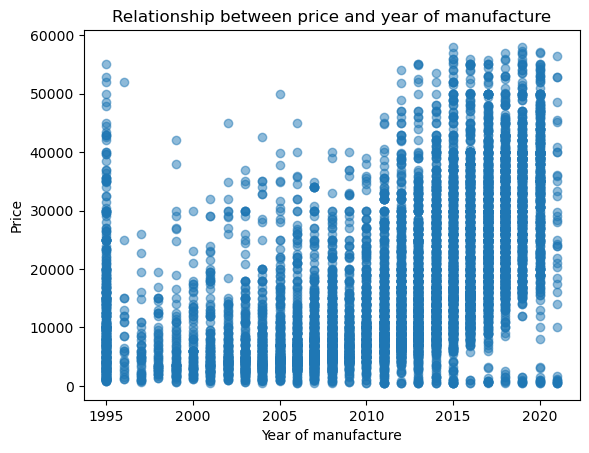

In [30]:
plt.figure()
plt.scatter(df_new['year'], df_new['price'], alpha=0.5)
plt.title('Relationship between price and year of manufacture')
plt.xlabel('Year of manufacture')
plt.ylabel('Price')
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
plt.show()

3. From the graph, I can conclude that there is an increasing trend: the newer the car, the higher its price. Exceptions are the oldest and the very newest vehicles. I check whether there is enough data for the years that deviate from the trend by displaying the number of cars produced each year, using grouping by year.

In [14]:
cars_per_year = df_new.groupby('year', as_index=False)['price'].count()
cars_per_year.columns = ['year', 'count']
cars_per_year

,year,count
0,1995,419
1,1996,25
2,1997,44
3,1998,55
4,1999,81
5,2000,78
6,2001,122
7,2002,149
8,2003,185
9,2004,208


4. Since there is little data for the last two years, I exclude them from the analysis. I filter the dataframe to keep only vehicles manufactured no later than 2021 and display the first five records.

In [15]:
df_new = df_new[df_new['year'] < 2022]
df_new.head()

,id,url,region,region_url,price,year,manufacturer,model,fuel,odometer,title_status,transmission,image_url,description,state,lat,long,posting_date,price_category,date
0,7308295377,https://chattanooga.craigslist.org/ctd/d/chatt...,chattanooga,https://chattanooga.craigslist.org,54990,2020,ram,2500 crew cab big horn,diesel,27442,clean,other,https://images.craigslist.org/00N0N_1xMPvfxRAI...,Carvana is the safer way to buy a car During t...,tn,35.060000,-85.250000,2021-04-17T12:30:50-0400,high,2021-04-17 16:30:50+00:00
1,7316380095,https://newjersey.craigslist.org/ctd/d/carlsta...,north jersey,https://newjersey.craigslist.org,16942,2016,ford,explorer 4wd 4dr xlt,other,60023,clean,automatic,https://images.craigslist.org/00x0x_26jl9F0cnL...,***Call Us for more information at: 201-635-14...,nj,40.821805,-74.061962,2021-05-03T15:40:21-0400,medium,2021-05-03 19:40:21+00:00
2,7313733749,https://reno.craigslist.org/ctd/d/atlanta-2017...,reno / tahoe,https://reno.craigslist.org,35590,2017,volkswagen,golf r hatchback,gas,14048,clean,other,https://images.craigslist.org/00y0y_eeZjWeiSfb...,Carvana is the safer way to buy a car During t...,ca,33.779214,-84.411811,2021-04-28T03:52:20-0700,high,2021-04-28 10:52:20+00:00
3,7308210929,https://fayetteville.craigslist.org/ctd/d/rale...,fayetteville,https://fayetteville.craigslist.org,14500,2013,toyota,rav4,gas,117291,clean,automatic,https://images.craigslist.org/00606_iGe5iXidib...,2013 Toyota RAV4 XLE 4dr SUV Offered by: R...,nc,35.715954,-78.655304,2021-04-17T10:08:57-0400,medium,2021-04-17 14:08:57+00:00
4,7316474668,https://newyork.craigslist.org/lgi/cto/d/baldw...,new york city,https://newyork.craigslist.org,21800,2021,nissan,altima,gas,8000,clean,automatic,https://images.craigslist.org/00V0V_3pSOiPZ3Sd...,2021 Nissan Altima Sv with Only 8 K Miles Titl...,ny,40.654800,-73.609700,2021-05-03T18:32:06-0400,medium,2021-05-03 22:32:06+00:00


5. On the filtered dataset, I repeat the steps to create a new dataframe containing statistics on the vehicle’s year of manufacture and the average price for cars of that year. I make sure to rename the columns according to their content.

In [16]:
df_year_stats = df_new.groupby('year', as_index=False).agg(averagePrice=('price', 'mean'))
df_year_stats['averagePrice'] = df_year_stats['averagePrice'].round(2)
df_year_stats.head()

,year,averagePrice
0,1995,13219.47
1,1996,9362.96
2,1997,6441.25
3,1998,6528.67
4,1999,7446.64


6. I create a line plot to visualize the relationship between vehicle price and year of manufacture, using the average prices calculated in the previous step. I set the line color to `blue`, the marker to a diamond (`D`), and the marker face color to `orange`. I also add a title and label both axes.

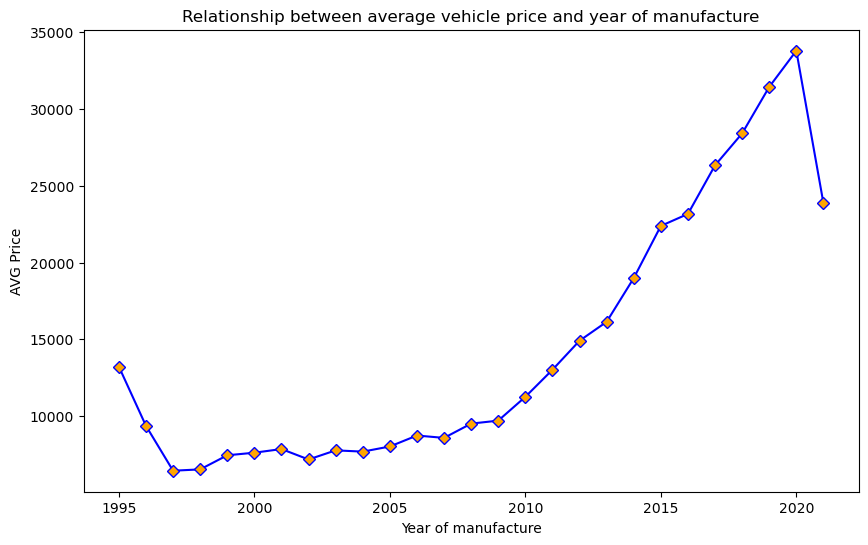

In [31]:
plt.figure(figsize=(10,6))
plt.plot(
    df_year_stats['year'], 
    df_year_stats['averagePrice'],
    color = 'blue',
    marker = 'D',
    markerfacecolor = 'orange'
)
plt.title('Relationship between average vehicle price and year of manufacture')
plt.xlabel('Year of manufacture')
plt.ylabel('AVG Price')
plt.show()

7. I calculate the Pearson correlation coefficient between vehicle price and year of manufacture. Based on the result, I answer the following questions:


    1. Can I conclude that there is a linear relationship between vehicle price and year of manufacture? Why?
    My answer: <b>Yes, there is a strong positive linear relationship because the Pearson correlation coefficient is 0.85 — which is close to 1 — indicating that as the year of manufacture increases, the average vehicle price also rises.</b>

    2. Can I conclude that there is a strong correlation between vehicle price and year of manufacture?
    My answer: <b>Yes, it can be said that there is a strong positive correlation, since the coefficient of 0.85 is close to 1, indicating a clear linear relationship: newer cars are generally more expensive.</b>

    3. Is the existing relationship direct or inverse? Why?
    My answer: <b>The existing relationship is direct: as the year of manufacture increases, the average vehicle price also rises.</b>

In [32]:
print('Pearson correlation coefficient between vehicle price and year of manufacture: ', df_year_stats['averagePrice'].corr(df_year_stats['year']))

Pearson correlation coefficient between vehicle price and year of manufacture:  0.8515488511221637


8. For the updated dataset, I plot a histogram of vehicle price distribution, setting the figure size to 8×5, the number of bins to 20, and the color to `indigo`. I also add a title and label both axes.

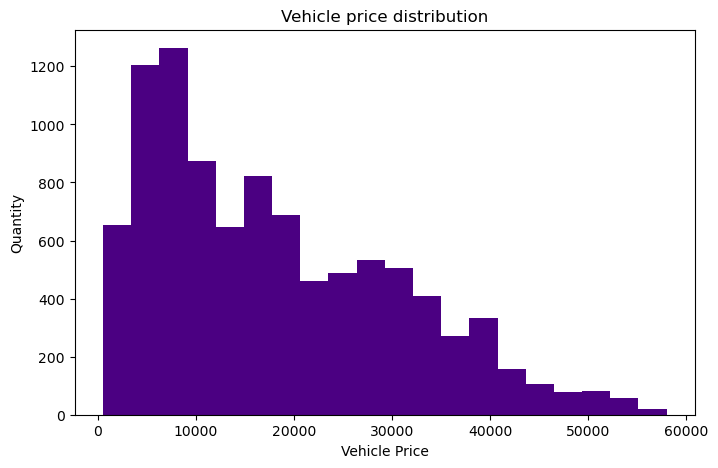

In [33]:
plt.figure(figsize=(8,5))
plt.hist(df_new['price'], bins=20, color='indigo')
plt.xlabel('Vehicle Price')
plt.ylabel('Quantity')
plt.title('Vehicle price distribution');

### Task 3. Exploring the relationship between car price category, price, and year of manufacture

1.plot the price distribution for each car price category on the same figure. I set the overall figure size to 12×8, the transparency (alpha) to 0.7, and use colors according to price category: green for low, orange for medium, and red for high. I add a title, label the axes, and include a legend for the price categories.

I analyze the resulting graph to understand why it looks the way it does: the distributions reflect how price categories are defined—low-priced cars cluster at lower values, high-priced cars cluster at higher values, and medium-priced cars overlap the two ranges. This explains the separation and overlap in the histograms.

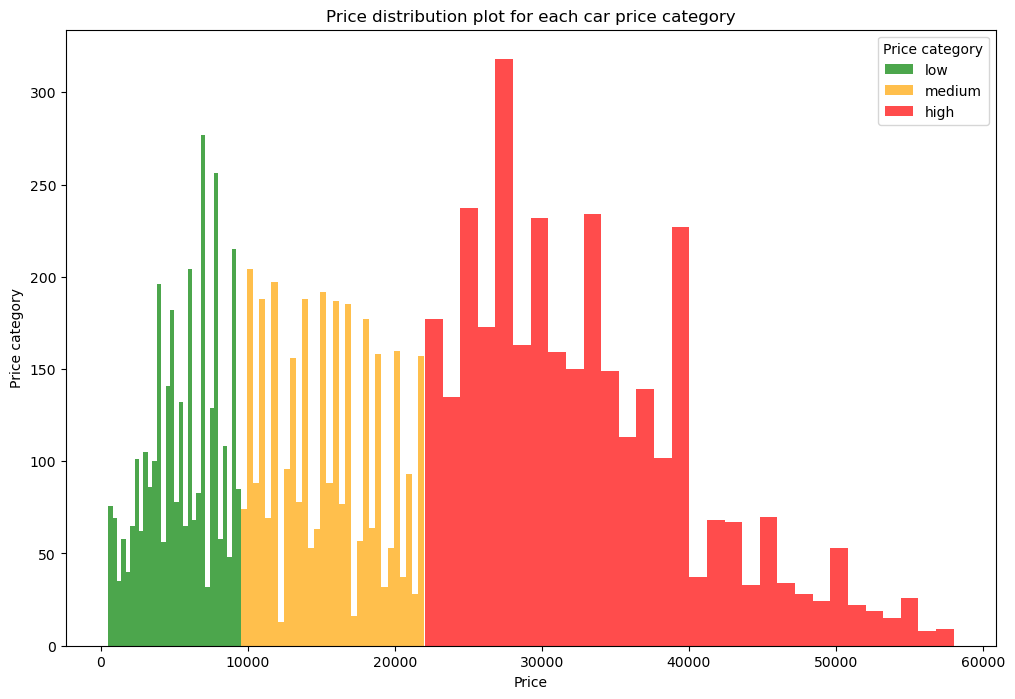

In [34]:
colors = {'low':'green', 'medium':'orange', 'high':'red'}
fig,ax = plt.subplots(figsize=(12,8))
for price_category in colors:
    color = colors[price_category]
    data = df_new[df_new['price_category'] == price_category]['price']
    ax.hist(data, color=color, label=price_category, alpha=0.7, bins=30)
ax.legend(loc='upper right', title='Price category')
plt.title('Price distribution plot for each car price category')
plt.xlabel('Price')
plt.ylabel('Price category')
plt.show()

2. I create a scatter plot of vehicle price versus year of manufacture on a single figure. I color each point according to the car’s price category, using green for low, orange for medium, and red for high. I set the figure size to 12×8, add a title and label the axes, and include a legend for the price categories, placing it in the lower right corner.

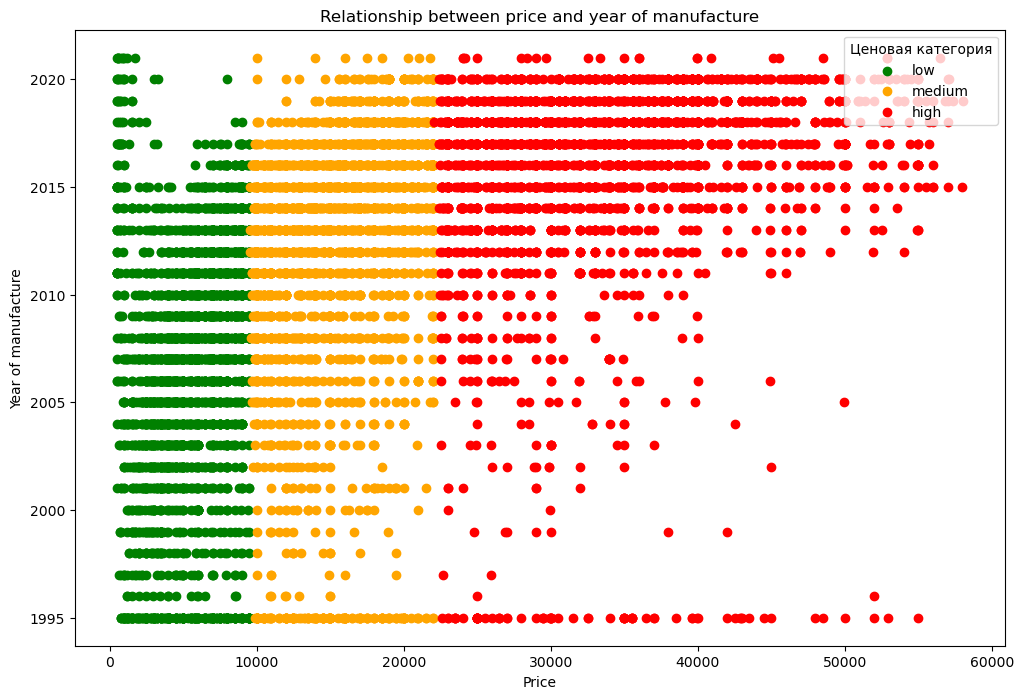

In [35]:
colors = {'low':'green', 'medium':'orange', 'high':'red'}
fig,ax = plt.subplots(figsize=(12,8))
for price_category in colors:
    color = colors[price_category]
    data = df_new[df_new['price_category'] == price_category]
    ax.scatter(data['price'], data['year'], c=color, label=price_category)
ax.legend(loc='upper right', title='Ценовая категория')
plt.title('Relationship between price and year of manufacture')
plt.xlabel('Price')
plt.ylabel('Year of manufacture')
plt.show()

### Task 4. Visualization of categorical variables

1. I create and display a new dataframe containing statistics on car manufacturers and the number of cars produced by each (using grouping). I make sure to rename the columns according to their content.


In [22]:
manufacturer_cars_stats = df_new.groupby('manufacturer', as_index=False)['id'].count()
manufacturer_cars_stats.columns = ['manufacturer', 'count_cars']
manufacturer_cars_stats

,manufacturer,count_cars
0,acura,149
1,alfa-romeo,13
2,audi,193
3,bmw,307
4,buick,145
5,cadillac,179
6,chevrolet,1243
7,chrysler,159
8,datsun,2
9,dodge,321


2.I create a bar chart for car manufacturers, setting the figure size to 20×10, the bar width (`width`) to 0.9, and alternating colors between `springgreen` and `dodgerblue`. I add a title and label the axes, and rotate the x-axis labels by 45 degrees using the `xticks` method with the `rotation` parameter.

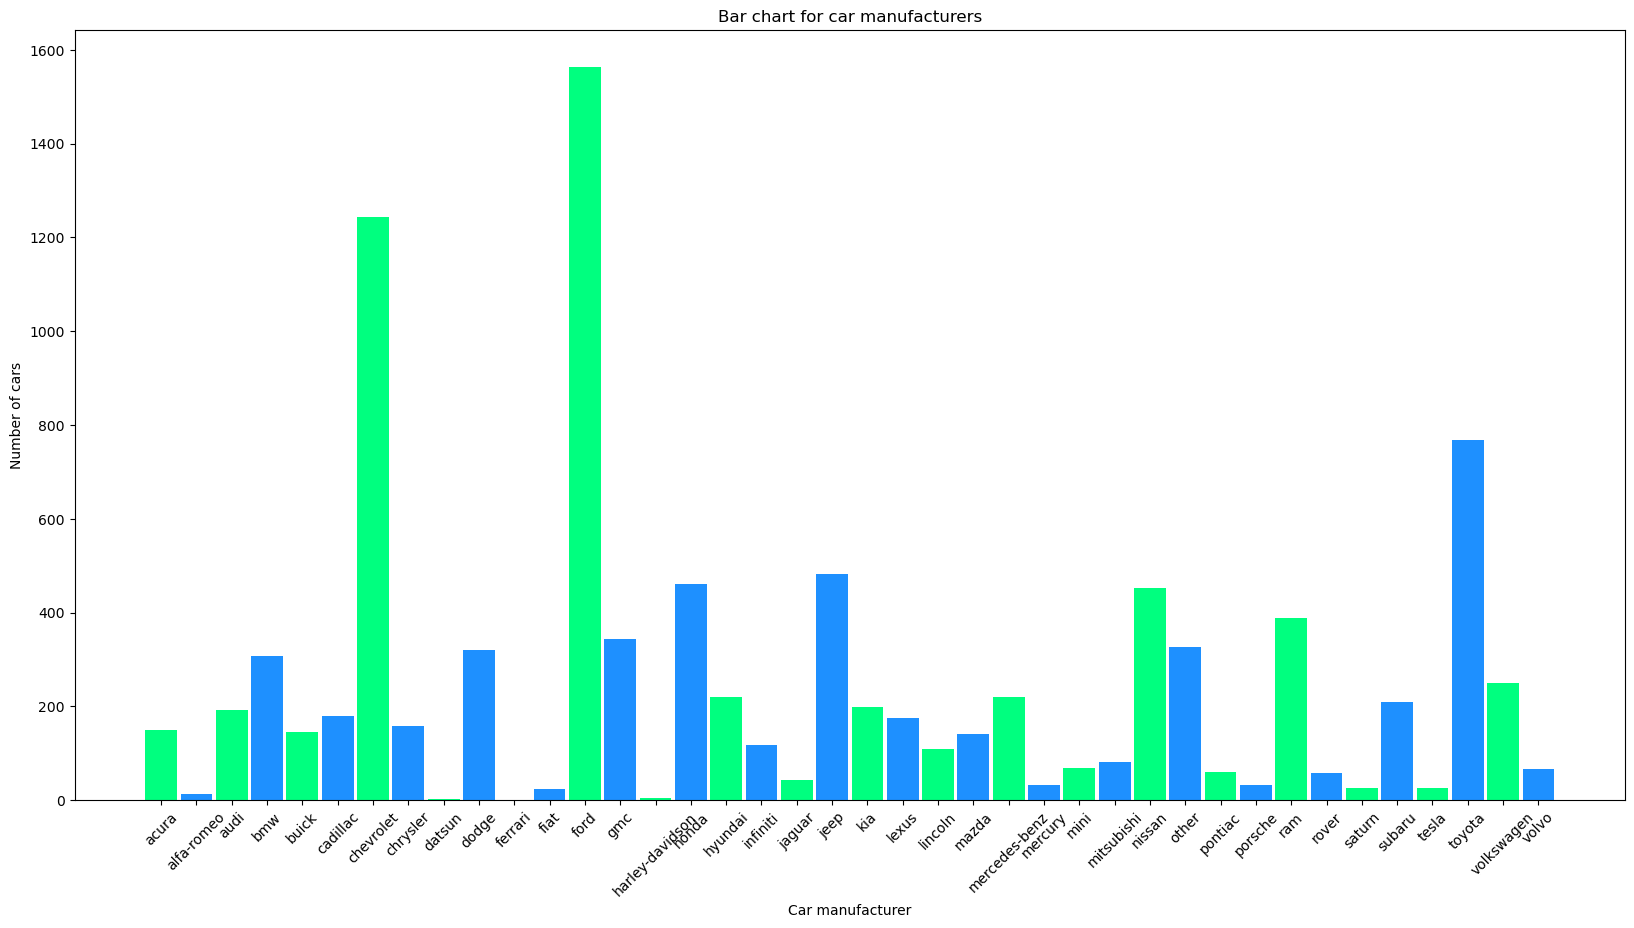

In [36]:
plt.figure(figsize=(20, 10))
colors = ['springgreen', 'dodgerblue']
plt.bar(
    manufacturer_cars_stats['manufacturer'],
    manufacturer_cars_stats['count_cars'],
    width=0.9,
    color=colors
)
plt.xlabel('Car manufacturer')
plt.ylabel('Number of cars')
plt.title('Bar chart for car manufacturers')
plt.xticks(rotation=45)
plt.show()

3. I create and display a new dataframe containing statistics on transmission types and the number of cars with each type (using grouping). I make sure to rename the columns according to their content.

In [24]:
transmission_cars_stats = df_new.groupby('transmission', as_index=False)['id'].count()
transmission_cars_stats.columns = ['transmission', 'count_cars']
transmission_cars_stats

,transmission,count_cars
0,automatic,7398
1,manual,612
2,other,1649


4. I create a pie chart for vehicle transmission types, setting the figure size to 12×8. I format the labels to show the proportion of each category and adjust the distance of the labels from the segment edges. I also add a title and display the legend separately.

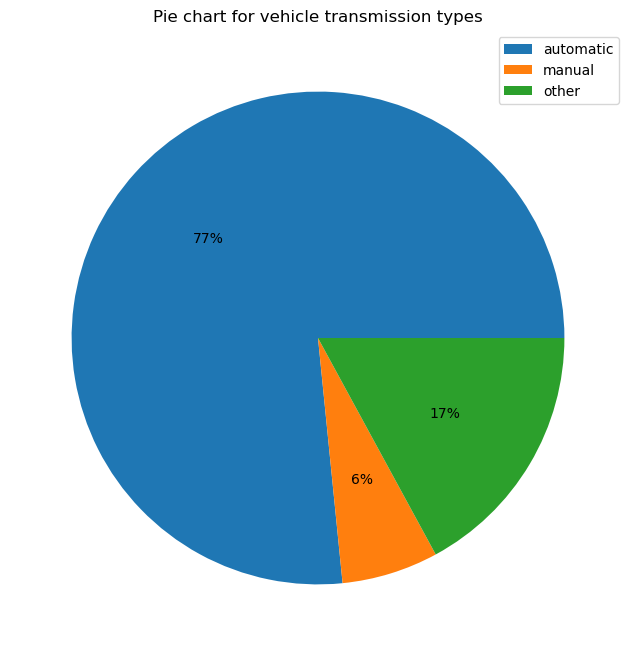

In [38]:
plt.figure(figsize=(12,8))
plt.pie(transmission_cars_stats['count_cars'], labels=transmission_cars_stats['transmission'], labeldistance=None, autopct='%1.0f%%')
plt.title('Pie chart for vehicle transmission types')
plt.legend()
plt.show()